# Pablo Prol Prieto and Pablo Sala Fernández (Team Pablo(s) in Kaggle)
## Session 4 notebook
---

## Table of Contents
---
1. [Objective](#objective)
2. [Data Loading](#data-loading)
3. [Data Review](#data-review)
4. [Strategy](#strategy)
5. [Data Augmentation](#data-augmentation)
6. [Model](#model)
7. [Training](#training)
8. [Analysis of Results](#analysis-of-results)
9. [Tuning the Model](#tuning-the-model)
    1. [Optimizer](#optimizer)
    2. [Learning Rate Scheduler](#learning-rate-scheduler)
    3. [Early Stopping](#early-stopping)
10. [Submission](#submission)

### Objective
---
In this notebook we are given multiple images of a particular park scenario captured at different times and with a different number of people in them. The objective is to create a Convolutional Neural Network to predict the number of people in the images.

### Imports
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import os
import random

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Since we will be using a Neural Network, we will use the GPU in order to speed up the training process. The following code cell will check if a GPU is available and if so, it will use it.

In [2]:
if tf.config.list_physical_devices('GPU'):
    print("GPU is available")
else:
    print("GPU is not available")

GPU is available


### Data loading
---

for loading the images we used the following code:

1. The code reads training data from a text file into a pandas DataFrame. The data consists of image filenames and corresponding labels.

2. It defines a function `load_and_process_image` to load and preprocess images. This function reads an image file, decodes it into a tensor, converts the tensor to float32, resizes the image, and returns the processed image along with its label.

3. A `tf.data.Dataset` is created from the filenames and labels. The `load_and_process_image` function is applied to each element in the dataset using the `map` method. Prefetching is enabled to improve performance.

4. The dataset is iterated over to convert the processed images and labels into numpy arrays, which are stored in `X` and `y` respectively. These arrays can be used as input to a machine learning model.

In [3]:
# Read the training data
df_train = pd.read_csv('/kaggle/input/learning2count/mlub-project-4-learning-to-count-2023-4/train.txt',sep=' ',header=None)

# read images and store into a numpy array
data_dir = '/kaggle/input/learning2count/mlub-project-4-learning-to-count-2023-4/train/train/'
im_size = 158

def load_and_process_image(filename, label):
    filename = tf.strings.join([data_dir, filename])
    im_file = tf.io.read_file(filename)
    # Use decode_jpeg or decode_png, depending on your image format
    im = tf.image.decode_png(im_file, channels=1)
    im = tf.image.convert_image_dtype(im, tf.float32)
    small_im = tf.image.resize(im, [im_size, im_size])
    return small_im, label

# Create a tf.data.Dataset
dataset = tf.data.Dataset.from_tensor_slices((df_train[0].values, df_train[1].values))
dataset = dataset.map(load_and_process_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)
dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)

# Convert the dataset to numpy arrays
X = []
y = []
for small_im, label in dataset:
    X.append(small_im.numpy())
    y.append(label)

X = np.array(X)
y = np.array(y)

The following cell prints a random image from the loaded dataset, this is merely for checking that the images are loaded correctly.

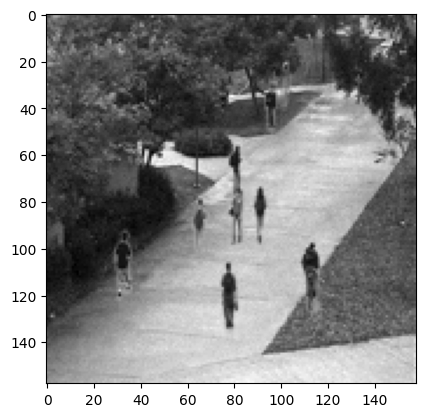

Image shape: (158, 158, 1)
Label(People in the image): 9


In [4]:
# Randomly select an index
index = random.randint(0, len(X) - 1)

# Display the image
plt.imshow(X[index], cmap='gray')
plt.show()

# Print the corresponding image shape and label
print("Image shape:", X[index].shape)
print("Label(People in the image):", y[index])

### Data review
---

In [5]:
# Number of images in the training dataset
print("Number of images in the training dataset:", len(X))
# Current image shape
print("Current image shape:", X[0].shape)
# Number of labels in the dataset
print("Number of labels in the dataset:", len(set(y)))

Number of images in the training dataset: 15000
Current image shape: (158, 158, 1)
Number of labels in the dataset: 30


In [6]:
df_train.describe()

,1
count,15000.000000
mean,14.377067
std,8.655134
min,0.000000
25%,7.000000
50%,14.000000
75%,22.000000
max,29.000000


From our data review, we can see that our dataset consists of 15000 images, these can have from 0 to 29 people in them.  
From the statistics shown by the previous describe() we can conclude that the number of images with a number of people is pretty much the same for all the possible values, this is good since it means that our dataset is balanced.
We chose the image size to be the same as the original one, 158x158, since we think that the images are not too big and we don't want to lose any information.

### Strategy
---
We will face this problem as a regression problem, since we want to predict a continuous value, the number of people in the image.  
We will apply data augmentation to our dataset, since we think that it will help our model to perform better.
We will use a Convolutional Neural Network with several convolutional layers and a few dense layers at the end.  
After training and validating our model, we will analyze the results and try to improve them by applying the necessary tuning strategies.

Let's start by splitting our data into training and validation sets, we will use 80% of the data for training and 20% for validation.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val= train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Data augmentation
---

Data augmentation is a technique to artificially increase the size of a dataset by applying transformations to the original images. This can help to improve the performance of a machine learning model. In this section, we will define transformations that will be applied later to our dataset.

In [8]:
def data_augmentation(image, label):
    # Randomly flip the image horizontally and vertically
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)

    # Randomly rotate the image
    image = tf.image.rot90(image, tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))

    # Randomly change brightness
    image = tf.image.random_brightness(image, max_delta=0.3)

    # Randomly change contrast
    image = tf.image.random_contrast(image, lower=0.7, upper=1.3)

    return image, label

# Convert the numpy arrays to a tf.data.Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))

# Apply the data augmentation
train_dataset = train_dataset.map(data_augmentation, num_parallel_calls=tf.data.experimental.AUTOTUNE)

# Convert the augmented dataset back to numpy arrays
X_train_augmented = []
y_train_augmented = []
for image, label in train_dataset:
    X_train_augmented.append(image.numpy())
    y_train_augmented.append(label.numpy())

X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(y_train_augmented)

# Join the original and augmented datasets
X_train_combined = np.concatenate((X_train, X_train_augmented))
y_train_combined = np.concatenate((y_train, y_train_augmented))

# Create an array of indices and shuffle it
indices = np.arange(X_train_combined.shape[0])
np.random.shuffle(indices)

# Use the shuffled indices to shuffle the datasets
X_train_combined = X_train_combined[indices]
y_train_combined = y_train_combined[indices]

# Rename the datasets back to X_train and y_train
X_train = X_train_combined
y_train = y_train_combined

### Model
---

In [9]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [10]:
'''from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten

model = keras.models.Sequential(layers=[
    Conv2D(filters=128, kernel_size=5, padding="same", activation="relu", input_shape=[im_size, im_size, 1]),
    Conv2D(filters=128, kernel_size=5, padding="same", activation="relu"),
    MaxPool2D(pool_size=2, strides=2, padding='valid'),

    Conv2D(filters=256, kernel_size=3, padding="same", activation="relu"),
    Conv2D(filters=256, kernel_size=3, padding="same", activation="relu"),
    MaxPool2D(pool_size=2, strides=2, padding='valid'),

    Conv2D(filters=512, kernel_size=3, padding="same", activation="relu"),
    Conv2D(filters=512, kernel_size=3, padding="same", activation="relu"),
    MaxPool2D(pool_size=2, strides=2, padding='valid'),

    Flatten(),
    Dense(1024, activation="relu"),
    Dense(512, activation="relu"),
    Dense(64, activation="relu"),
    keras.layers.Dense(1, activation="linear")
])'''

'from tensorflow.keras.layers import Conv2D\nfrom tensorflow.keras.layers import MaxPool2D\nfrom tensorflow.keras.layers import Dense\nfrom tensorflow.keras.layers import Flatten\n\nmodel = keras.models.Sequential(layers=[\n    Conv2D(filters=128, kernel_size=5, padding="same", activation="relu", input_shape=[im_size, im_size, 1]),\n    Conv2D(filters=128, kernel_size=5, padding="same", activation="relu"),\n    MaxPool2D(pool_size=2, strides=2, padding=\'valid\'),\n\n    Conv2D(filters=256, kernel_size=3, padding="same", activation="relu"),\n    Conv2D(filters=256, kernel_size=3, padding="same", activation="relu"),\n    MaxPool2D(pool_size=2, strides=2, padding=\'valid\'),\n\n    Conv2D(filters=512, kernel_size=3, padding="same", activation="relu"),\n    Conv2D(filters=512, kernel_size=3, padding="same", activation="relu"),\n    MaxPool2D(pool_size=2, strides=2, padding=\'valid\'),\n\n    Flatten(),\n    Dense(1024, activation="relu"),\n    Dense(512, activation="relu"),\n    Dense(64,

SACNN

In [11]:
'''from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization
from keras.layers import concatenate

# Define the input shape
input_shape = (im_size, im_size, 1)  # adjust this to match your actual input shape

# Define the input layer
input_layer = Input(shape=input_shape)

# Define the scale-adaptive layers
scale1 = Conv2D(32, (3, 3), activation='relu')(input_layer)
scale1 = BatchNormalization()(scale1)
scale1 = MaxPooling2D(pool_size=(2, 2))(scale1)
scale1 = Conv2D(64, (3, 3), activation='relu')(scale1)
scale1 = BatchNormalization()(scale1)
scale1 = MaxPooling2D(pool_size=(2, 2))(scale1)
scale1 = Flatten()(scale1)
scale1 = Dense(128, activation='relu')(scale1)

scale2 = Conv2D(32, (5, 5), activation='relu')(input_layer)
scale2 = BatchNormalization()(scale2)
scale2 = MaxPooling2D(pool_size=(2, 2))(scale2)
scale2 = Conv2D(64, (5, 5), activation='relu')(scale2)
scale2 = BatchNormalization()(scale2)
scale2 = MaxPooling2D(pool_size=(2, 2))(scale2)
scale2 = Flatten()(scale2)
scale2 = Dense(128, activation='relu')(scale2)

# Concatenate the outputs of the base model and the scale-adaptive layers
concat = concatenate([scale1, scale2])

# Add Dense layers with ReLU activation
dense1 = Dense(1024, activation='relu')(concat)
dense2 = Dense(512, activation='relu')(dense1)
dense3 = Dense(64, activation='relu')(dense2)

# Add a final Dense layer with linear activation
output_layer = Dense(1, activation='linear')(dense3)

# Define the model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')'''

"from keras.models import Model\nfrom keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization\nfrom keras.layers import concatenate\n\n# Define the input shape\ninput_shape = (im_size, im_size, 1)  # adjust this to match your actual input shape\n\n# Define the input layer\ninput_layer = Input(shape=input_shape)\n\n# Define the scale-adaptive layers\nscale1 = Conv2D(32, (3, 3), activation='relu')(input_layer)\nscale1 = BatchNormalization()(scale1)\nscale1 = MaxPooling2D(pool_size=(2, 2))(scale1)\nscale1 = Conv2D(64, (3, 3), activation='relu')(scale1)\nscale1 = BatchNormalization()(scale1)\nscale1 = MaxPooling2D(pool_size=(2, 2))(scale1)\nscale1 = Flatten()(scale1)\nscale1 = Dense(128, activation='relu')(scale1)\n\nscale2 = Conv2D(32, (5, 5), activation='relu')(input_layer)\nscale2 = BatchNormalization()(scale2)\nscale2 = MaxPooling2D(pool_size=(2, 2))(scale2)\nscale2 = Conv2D(64, (5, 5), activation='relu')(scale2)\nscale2 = BatchNormalization()(scale2)\nscale

MCNN

In [12]:
'''from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from keras.layers import concatenate

# Define the input shape
input_shape = (im_size, im_size, 1)  # adjust this to match your actual input shape

# Define the input layer
input_layer = Input(shape=input_shape)

# Define the first column
column1 = Conv2D(16, (9, 9), activation='relu')(input_layer)
column1 = MaxPooling2D(pool_size=(2, 2))(column1)
column1 = Conv2D(32, (7, 7), activation='relu')(column1)
column1 = MaxPooling2D(pool_size=(2, 2))(column1)
column1 = Conv2D(16, (7, 7), activation='relu')(column1)
column1 = Conv2D(8, (7, 7), activation='relu')(column1)
column1 = Flatten()(column1)

# Define the second column
column2 = Conv2D(20, (7, 7), activation='relu')(input_layer)
column2 = MaxPooling2D(pool_size=(2, 2))(column2)
column2 = Conv2D(40, (5, 5), activation='relu')(column2)
column2 = MaxPooling2D(pool_size=(2, 2))(column2)
column2 = Conv2D(20, (5, 5), activation='relu')(column2)
column2 = Conv2D(10, (5, 5), activation='relu')(column2)
column2 = Flatten()(column2)

# Define the third column
column3 = Conv2D(24, (5, 5), activation='relu')(input_layer)
column3 = MaxPooling2D(pool_size=(2, 2))(column3)
column3 = Conv2D(48, (3, 3), activation='relu')(column3)
column3 = MaxPooling2D(pool_size=(2, 2))(column3)
column3 = Conv2D(24, (3, 3), activation='relu')(column3)
column3 = Conv2D(12, (3, 3), activation='relu')(column3)
column3 = Flatten()(column3)

# Concatenate the outputs of the three columns
concat = concatenate([column1, column2, column3])

# Add Dense layers with ReLU activation
dense1 = Dense(1024, activation='relu')(concat)
dense2 = Dense(512, activation='relu')(dense1)
dense3 = Dense(64, activation='relu')(dense2)

# Add a final Dense layer with linear activation
output_layer = Dense(1, activation='linear')(dense3)

# Define the model
model = Model(inputs=input_layer, outputs=output_layer)'''

"from keras.models import Model\nfrom keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense\nfrom keras.layers import concatenate\n\n# Define the input shape\ninput_shape = (im_size, im_size, 1)  # adjust this to match your actual input shape\n\n# Define the input layer\ninput_layer = Input(shape=input_shape)\n\n# Define the first column\ncolumn1 = Conv2D(16, (9, 9), activation='relu')(input_layer)\ncolumn1 = MaxPooling2D(pool_size=(2, 2))(column1)\ncolumn1 = Conv2D(32, (7, 7), activation='relu')(column1)\ncolumn1 = MaxPooling2D(pool_size=(2, 2))(column1)\ncolumn1 = Conv2D(16, (7, 7), activation='relu')(column1)\ncolumn1 = Conv2D(8, (7, 7), activation='relu')(column1)\ncolumn1 = Flatten()(column1)\n\n# Define the second column\ncolumn2 = Conv2D(20, (7, 7), activation='relu')(input_layer)\ncolumn2 = MaxPooling2D(pool_size=(2, 2))(column2)\ncolumn2 = Conv2D(40, (5, 5), activation='relu')(column2)\ncolumn2 = MaxPooling2D(pool_size=(2, 2))(column2)\ncolumn2 = Conv2D(20, (5, 5), a

Deep CNN

In [13]:
'''from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, AveragePooling2D, Flatten, Dense
from keras.layers import concatenate

# Define the input shape
input_shape = (im_size, im_size, 1)  # adjust this to match your actual input shape

# Define the input layer
input_layer = Input(shape=input_shape)

# Define the deep network
deep = Conv2D(64, (3, 3), activation='relu', padding='same')(input_layer)
deep = Conv2D(64, (3, 3), activation='relu', padding='same')(deep)
deep = MaxPooling2D(pool_size=(2, 2), padding='same')(deep)
deep = Conv2D(128, (3, 3), activation='relu', padding='same')(deep)
deep = Conv2D(128, (3, 3), activation='relu', padding='same')(deep)
deep = MaxPooling2D(pool_size=(2, 2), padding='same')(deep)
deep = Conv2D(256, (3, 3), activation='relu', padding='same')(deep)
deep = Conv2D(256, (3, 3), activation='relu', padding='same')(deep)
deep = Conv2D(256, (3, 3), activation='relu', padding='same')(deep)
deep = MaxPooling2D(pool_size=(2, 2), padding='same')(deep)
deep = Conv2D(512, (3, 3), activation='relu', padding='same')(deep)
deep = Conv2D(512, (3, 3), activation='relu', padding='same')(deep)
deep = Conv2D(512, (3, 3), activation='relu', padding='same')(deep)
deep = MaxPooling2D(pool_size=(2, 2), padding='same')(deep)
deep = Conv2D(1024, (3, 3), activation='relu', padding='same')(deep)
deep = Conv2D(1024, (3, 3), activation='relu', padding='same')(deep)
deep = Conv2D(1024, (3, 3), activation='relu', padding='same')(deep)
deep = Flatten()(deep)

# Define the shallow network
shallow = Conv2D(24, (5, 5), activation='relu', padding='same')(input_layer)
shallow = AveragePooling2D(pool_size=(5, 5), padding='same')(shallow)
shallow = Conv2D(24, (5, 5), activation='relu', padding='same')(shallow)
shallow = AveragePooling2D(pool_size=(5, 5), padding='same')(shallow)
shallow = Conv2D(24, (5, 5), activation='relu', padding='same')(shallow)
shallow = AveragePooling2D(pool_size=(5, 5), padding='same')(shallow)
shallow = Flatten()(shallow)

# Concatenate the outputs of the deep and shallow networks
concat = concatenate([deep, shallow])

# Add Dense layers with ReLU activation
dense1 = Dense(1024, activation='relu')(concat)
dense2 = Dense(512, activation='relu')(dense1)
dense3 = Dense(64, activation='relu')(dense2)

# Add a final Dense layer with linear activation
output_layer = Dense(1, activation='linear')(dense3)

# Define the model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')'''

"from keras.models import Model\nfrom keras.layers import Input, Conv2D, MaxPooling2D, AveragePooling2D, Flatten, Dense\nfrom keras.layers import concatenate\n\n# Define the input shape\ninput_shape = (im_size, im_size, 1)  # adjust this to match your actual input shape\n\n# Define the input layer\ninput_layer = Input(shape=input_shape)\n\n# Define the deep network\ndeep = Conv2D(64, (3, 3), activation='relu', padding='same')(input_layer)\ndeep = Conv2D(64, (3, 3), activation='relu', padding='same')(deep)\ndeep = MaxPooling2D(pool_size=(2, 2), padding='same')(deep)\ndeep = Conv2D(128, (3, 3), activation='relu', padding='same')(deep)\ndeep = Conv2D(128, (3, 3), activation='relu', padding='same')(deep)\ndeep = MaxPooling2D(pool_size=(2, 2), padding='same')(deep)\ndeep = Conv2D(256, (3, 3), activation='relu', padding='same')(deep)\ndeep = Conv2D(256, (3, 3), activation='relu', padding='same')(deep)\ndeep = Conv2D(256, (3, 3), activation='relu', padding='same')(deep)\ndeep = MaxPooling2D(p

In [14]:
'''model.summary()'''

'model.summary()'

### Training
---

In [15]:
'''model.compile(loss="mean_squared_error",
              optimizer="Adam")

history = model.fit(X_train, y_train, epochs=15, batch_size=30,
                    validation_data=(X_val, y_val), verbose=1)'''

'model.compile(loss="mean_squared_error",\n              optimizer="Adam")\n\nhistory = model.fit(X_train, y_train, epochs=15, batch_size=30,\n                    validation_data=(X_val, y_val), verbose=1)'

### Analysis of results
---

This code is used to visualize the training and validation loss of a model during its training process, which can be useful for diagnosing issues like overfitting (where the training loss continues to decrease, but the validation loss starts to increase or remains unchanged).

In [16]:
'''pd.DataFrame(history.history)[['loss','val_loss']].plot(figsize=(8, 5))
plt.xlabel('Epochs')
plt.grid(True)
plt.show()'''

"pd.DataFrame(history.history)[['loss','val_loss']].plot(figsize=(8, 5))\nplt.xlabel('Epochs')\nplt.grid(True)\nplt.show()"

From the graph we can see that starting from the 10th epoch the validation loss stops decreasing while the training loss continues to decrease, this means that our model is starting to overfit.

Next, we will plot the root mean squared error (RMSE) of the predictions on the validation set. The RMSE is the evaluation metric for this competition.

In [17]:
'''from sklearn.metrics import mean_squared_error
y_model1 = model.predict(X_val)

plt.plot(y_model1,y_val,'.')
plt.plot([0, np.max(y_val)], [0, np.max(y_val)], 'r--')  # Adding the straight line y = x
plt.xlabel('Predicted Values')
plt.ylabel('True Values')

print('RMSE: ', np.sqrt(mean_squared_error(y_model1,y_val)))'''

"from sklearn.metrics import mean_squared_error\ny_model1 = model.predict(X_val)\n\nplt.plot(y_model1,y_val,'.')\nplt.plot([0, np.max(y_val)], [0, np.max(y_val)], 'r--')  # Adding the straight line y = x\nplt.xlabel('Predicted Values')\nplt.ylabel('True Values')\n\nprint('RMSE: ', np.sqrt(mean_squared_error(y_model1,y_val)))"

### Tuning the model
---

#### Optimizer

We will start by tuning the optimizer, which is the function used during training to reach the minimum of the loss function by nudging the parameters. We will use the Adam optimizer, which is a popular optimizer that works well for many problems. We will try different values for the learning rate, which determines the size of the "nudges" made to the parameters.

In [18]:
from tensorflow.keras.optimizers import Adam
# The Adam optimization algorithm is an extension to stochastic gradient descent, it is usually more effective and fast.
optimizer = Adam(
    # The most important parameter is the learning rate - controls the amount that the weights are updated during each round of training.
    learning_rate=0.0001,
    # Additional parameters to play with:
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=True,
)

#### Learning rate scheduler

We will also use a learning rate scheduler to decrease the learning rate as the training progresses. This can help to improve the performance of the model, since it allows the model to make large updates to the parameters at the beginning of training, and small updates towards the end of training thus efficiently reaching a minimum of the loss function.  
Moreover, this keeps the advantages of using a high learning rate at the beginning of training (convergence speed) without the disadvantages (instability).

In [19]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
# The LR is decreased dynamically when the score is not improved. This keeps the advantage of the fast computation time with a high LR at the start.
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_loss',  # Track the score on the validation set
    patience=2,  # number of epochs with no improvement after which learning rate will be reduced.
    verbose=1, 
    factor=0.2,  # Factor by which the LR is multiplied.
    min_lr=0.000001  # Don't go below this value for LR.
)

#### Early stopping

We will use early stopping to stop the training process early if the validation loss stops decreasing for several epochs. This helps to prevent overfitting.

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',   # The quantity to monitor. In this case, we are monitoring the validation loss.
    mode='min',  # One of {"auto", "min", "max"}. In this case, we want to minimize the validation loss, so we set it to "min".
    verbose=1,
    patience=3  # Number of epochs with no improvement after which training will be stopped.
)

### Submission
---

Now that we have tuned our model, we can use it to generate predictions for the test set. In this section we will train the model on the entire training set, generate predictions for the test set, and create a submission file.

Read the test data

In [21]:
# Get a list of all the test image filenames
test_filenames = os.listdir('/kaggle/input/learning2count/mlub-project-4-learning-to-count-2023-4/test/test/test/')

# Define the directory for the test images
data_dir_test = '/kaggle/input/learning2count/mlub-project-4-learning-to-count-2023-4/test/test/test/'

def load_and_process_test_image(filename):
    filename = tf.strings.join([data_dir_test, filename])
    im_file = tf.io.read_file(filename)
    # Use decode_jpeg or decode_png, depending on your image format
    im = tf.image.decode_png(im_file, channels=1)
    im = tf.image.convert_image_dtype(im, tf.float32)
    small_im = tf.image.resize(im, [im_size, im_size])
    return small_im

# Create a tf.data.Dataset
test_dataset = tf.data.Dataset.from_tensor_slices(test_filenames)
test_dataset = test_dataset.map(load_and_process_test_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.experimental.AUTOTUNE)

# Convert the dataset to numpy arrays
X_test = []
for small_im in test_dataset:
    X_test.append(small_im.numpy())

X_test = np.array(X_test)

Train the model on a bigger portion of the training set and generate submission for the test set

In [22]:
# Determine the number of samples to select
num_samples = X_val.shape[0] // 2

# Create an array of indices, shuffle it, and select the first half
indices = np.arange(X_val.shape[0])
np.random.shuffle(indices)
selected_indices = indices[:num_samples]

# Select half of the validation data
X_val_selected = X_val[selected_indices]
y_val_selected = y_val[selected_indices]

# Concatenate the selected validation data with the training data
X_train = np.concatenate((X_train, X_val_selected))
y_train = np.concatenate((y_train, y_val_selected))

# Create an array of indices for the new training set and shuffle it
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)

# Use the shuffled indices to shuffle the new training set
X_train = X_train[indices]
y_train = y_train[indices]

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten

model = keras.models.Sequential(layers=[
    Conv2D(filters=32, kernel_size=5, padding="same", activation="relu", input_shape=[im_size, im_size, 1]),
    Conv2D(filters=32, kernel_size=5, padding="same", activation="relu"),
    MaxPool2D(pool_size=2, strides=2, padding='valid'),

    Conv2D(filters=64, kernel_size=3, padding="same", activation="relu"),
    Conv2D(filters=64, kernel_size=3, padding="same", activation="relu"),
    MaxPool2D(pool_size=2, strides=2, padding='valid'),

    Conv2D(filters=128, kernel_size=2, padding="same", activation="relu"),
    Conv2D(filters=128, kernel_size=2, padding="same", activation="relu"),
    MaxPool2D(pool_size=2, strides=2, padding='valid'),

    Flatten(),
    Dense(1024, activation="relu"),
    Dense(512, activation="relu"),
    Dense(64, activation="relu"),
    keras.layers.Dense(1, activation="linear")
])

# Compile the model
model.compile(loss="mean_squared_error", optimizer=optimizer)

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), verbose=1, callbacks=[learning_rate_reduction, early_stopping])

# Generate predictions for the test set
predictions = model.predict(X_test)

# Create a DataFrame for the submission file
df_output = pd.DataFrame(predictions.flatten())
df_output.index.name = 'index'
df_output.columns = ['prediction']

# Save the submission file
df_output.to_csv('/kaggle/working/submission.csv')

Epoch 1/50
797/797 [==============================] - 48s 45ms/step - loss: 20.3474 - val_loss: 3.2862 - lr: 1.0000e-04
Epoch 2/50
797/797 [==============================] - 34s 43ms/step - loss: 5.6378 - val_loss: 3.3769 - lr: 1.0000e-04
Epoch 3/50
797/797 [==============================] - 34s 43ms/step - loss: 4.3626 - val_loss: 3.1629 - lr: 1.0000e-04
Epoch 4/50
797/797 [==============================] - 34s 43ms/step - loss: 3.4002 - val_loss: 4.4398 - lr: 1.0000e-04
Epoch 5/50
797/797 [==============================] - 34s 43ms/step - loss: 2.6520 - val_loss: 2.1874 - lr: 1.0000e-04
Epoch 6/50
797/797 [==============================] - 34s 43ms/step - loss: 2.4735 - val_loss: 1.4499 - lr: 1.0000e-04
Epoch 7/50
797/797 [==============================] - 34s 43ms/step - loss: 2.1784 - val_loss: 1.3690 - lr: 1.0000e-04
Epoch 8/50
797/797 [==============================] - 34s 43ms/step - loss: 1.9435 - val_loss: 1.6560 - lr: 1.0000e-04
Epoch 9/50
797/797 [===========================

Finally, we will visualize the final model results on the validation set (which has been reduced to half with respect to the validation set used to train the first model).

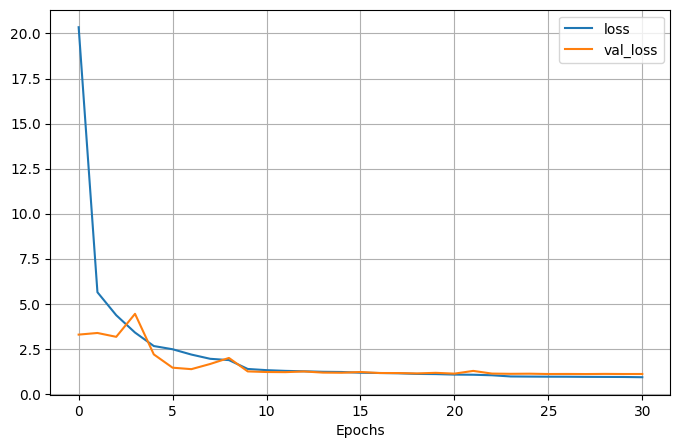

In [23]:
pd.DataFrame(history.history)[['loss','val_loss']].plot(figsize=(8, 5))
plt.xlabel('Epochs')
plt.grid(True)
plt.show()

94/94 [==============================] - 1s 11ms/step
RMSE:  1.0489489256940898


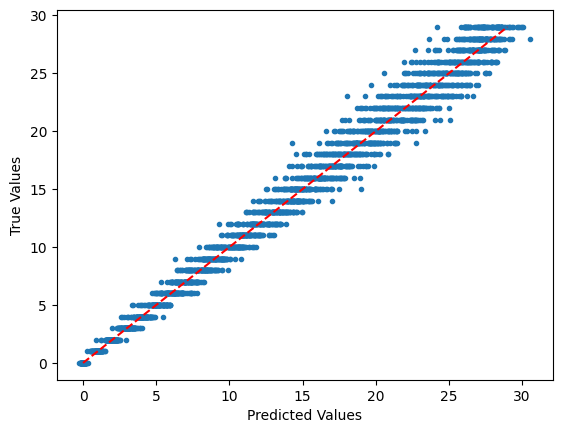

In [24]:
from sklearn.metrics import mean_squared_error
y_model1 = model.predict(X_val)

plt.plot(y_model1,y_val,'.')
plt.plot([0, np.max(y_val)], [0, np.max(y_val)], 'r--')  # Adding the straight line y = x
plt.xlabel('Predicted Values')
plt.ylabel('True Values')

print('RMSE: ', np.sqrt(mean_squared_error(y_model1,y_val)))